# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, math, time, subprocess
import numpy as np, torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Thư mục gốc repo (chứa data/ và scripts/): ".." khi chạy trong code/ của repo, "../.." khi chạy trong submission_<MSSV>/code/
REPO_ROOT = next((p for p in ("..", "../..") if os.path.exists(f"{p}/scripts/split_data.py")), "../..")
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, rồi đặt REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

# GPU CUDA nếu có (Colab/Kaggle). Không có CUDA thì dùng CPU: trên Mac M4 đã đo MPS CHẬM hơn CPU với MLP nhỏ này
# (~1.5 s so với ~0.4 s mỗi epoch) vì chi phí gọi kernel lấn át lượng tính toán.
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", device,
      "|", torch.cuda.get_device_name(0) if device == "cuda" else f"CPU, {torch.get_num_threads()} luồng")
print("REPO_ROOT =", os.path.abspath(REPO_ROOT), "| OUT_DIR =", os.path.abspath(OUT_DIR))
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import (DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval,
                   compute_loss, macro_f1_from_confusion)
from plots import plot_run, plot_compare, plot_lr_sensitivity
from results_table import save_result, load_results, to_row, write_xlsx

torch 2.8.0 | device: cpu | CPU, 4 luồng
REPO_ROOT = /Users/tienanh211/K4-Track4-Day1-DinhLenhTienAnh-2A202602928-Neuralnetwork | OUT_DIR = /Users/tienanh211/K4-Track4-Day1-DinhLenhTienAnh-2A202602928-Neuralnetwork/submission_2A202602928


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
# 1. Chia train/eval theo metadata có sẵn (không sửa metadata). Script tự kiểm tra toàn vẹn và in tỉ lệ lớp.
out = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True, capture_output=True, text=True)
print(out.stdout)

# 2-4. Tách val 20% từ train (phân tầng, seed 42) -> chuẩn hoá 10 cột số bằng mean/std của phần train còn lại
#      -> đưa toàn bộ tensor lên device một lần (không DataLoader)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876



train 371,847 | val 92,962 | eval 116,203  (device=cpu)
"luôn đoán lớp 1" trên val: accuracy = 0.4876


In [3]:
# Tự kiểm tra Part 0
X_tr, y_tr, X_val, y_val = data["X_tr"], data["y_tr"], data["X_val"], data["y_val"]
y_eval = data["y_eval"]   # chỉ dùng để so tỉ lệ lớp; X_eval không đi vào bước chuẩn hoá/chọn cấu hình nào
assert (len(X_tr), len(X_val), len(data["X_eval"])) == (371_847, 92_962, 116_203)
assert X_tr.dtype == torch.float32 and y_tr.dtype == torch.int64 and X_tr.shape[1] == 54

# (a) tỉ lệ lớp ở train / val / eval
props = {n: torch.bincount(y, minlength=7).cpu().numpy() / len(y) for n, y in (("train", y_tr), ("val", y_val), ("eval", y_eval))}
print("lớp    train%     val%    eval%")
for c in range(7):
    print(f"{c:>3d}  " + "  ".join(f"{100 * props[n][c]:7.3f}" for n in props))

# (b) 10 cột số: mean/std trên phần train còn lại phải ≈ 0 / 1; 44 cột nhị phân giữ nguyên {0, 1}
num = X_tr[:, :10].double()
print("\nmean 10 cột số (train):", np.round(num.mean(0).cpu().numpy(), 4))
print("std  10 cột số (train):", np.round(num.std(0).cpu().numpy(), 4))
print("std  10 cột số (val)  :", np.round(X_val[:, :10].double().std(0).cpu().numpy(), 4), " (dùng mean/std của train nên chỉ ≈ 1)")
assert num.mean(0).abs().max() < 1e-4 and (num.std(0) - 1).abs().max() < 1e-3
assert set(torch.unique(X_tr[:, 10:]).tolist()) == {0.0, 1.0}

# (c) mốc thấp nhất: "luôn đoán lớp đa số" (lớp đa số xác định trên train) trên val
maj = int(torch.bincount(y_tr).argmax())
cm_maj = np.zeros((7, 7), dtype=np.int64)
cm_maj[:, maj] = np.bincount(y_val.cpu().numpy(), minlength=7)
MAJ_ACC = float((y_val == maj).float().mean())
MAJ_F1 = macro_f1_from_confusion(cm_maj)
print(f'\n"luôn đoán lớp {maj}" trên val: accuracy = {MAJ_ACC:.4f}, macro-F1 = {MAJ_F1:.4f}')

lớp    train%     val%    eval%
  0   36.461   36.460   36.460
  1   48.760   48.760   48.760
  2    6.154    6.154    6.154
  3    0.473    0.472    0.472
  4    1.634    1.634    1.634
  5    2.989    2.989    2.989
  6    3.530    3.530    3.530

mean 10 cột số (train): [-0. -0. -0.  0. -0. -0. -0. -0. -0.  0.]
std  10 cột số (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
std  10 cột số (val)  : [0.9981 1.0011 0.9981 1.0037 0.9995 1.0043 1.0009 0.9998 0.9993 1.0035]  (dùng mean/std của train nên chỉ ≈ 1)



"luôn đoán lớp 1" trên val: accuracy = 0.4876, macro-F1 = 0.0936


**Nhận xét Part 0:**
- Kích thước khớp yêu cầu: train 464 809 → **371 847 train + 92 962 val** (20%, phân tầng, `random_state=42`); eval 116 203. Tỉ lệ lớp ở ba tập gần như trùng nhau (chênh < 0,01 điểm %) nhờ phân tầng. Dữ liệu rất mất cân bằng: lớp 1 chiếm 48,8%, lớp 3 chỉ 0,47%.
- Sau chuẩn hoá, 10 cột số trên phần train còn lại có mean = 0, std = 1. Trên val, std chỉ **xấp xỉ** 1 vì val dùng lại mean/std của train. 44 cột one-hot giữ nguyên giá trị {0, 1}.
- Mốc thấp nhất: "luôn đoán lớp 1" có val accuracy **0,4876** nhưng macro-F1 chỉ **0,0937**. Mọi mô hình phải vượt mốc này, và macro-F1 mới phản ánh đúng chất lượng trên các lớp hiếm.
- **Vì sao chỉ tính mean/std trên phần train?** Val và eval đóng vai dữ liệu "chưa thấy". Nếu dùng thống kê của chúng để chuẩn hoá thì thông tin về phân phối của tập đánh giá đã rò vào bước tiền xử lý (rò rỉ dữ liệu), làm điểm val/eval lạc quan hơn thực tế. Khi triển khai thật, ta cũng chỉ có thống kê của dữ liệu huấn luyện. Trong code, `fit_standardizer` chỉ nhận `X_tr`, còn `X_eval` chỉ được *áp dụng* cùng mean/std đó và không tham gia chuẩn hoá, chọn cấu hình hay dừng sớm.

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

In [4]:
# 1a-1b. Model M-base: 54 -> 256 -> 128 -> 7, ReLU, He init, không dropout; kiểm tra số tham số và shape
set_seed(1)   # cùng seed với base-s1 ở Part 2 -> cùng trọng số khởi tạo
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879
print(model)
print(f"số tham số: {n_params:,}\n")

xb8 = torch.randn(8, 54, device=device)
h = xb8
print(f"{'input':<45s} {tuple(h.shape)}")
for layer in model.net:
    h = layer(h)
    print(f"{str(layer):<45s} {tuple(h.shape)}")
logits = model(xb8)
assert logits.shape == (8, 7) and logits.dtype == torch.float32

# He init thật sự được áp dụng (không phải mặc định của nn.Linear): std(W) ≈ sqrt(2 / n_vào), bias = 0
print()
for i, lin in enumerate((l for l in model.net if isinstance(l, nn.Linear)), 1):
    print(f"W{i}: std = {lin.weight.std().item():.4f}  (He: sqrt(2/{lin.in_features}) = {math.sqrt(2 / lin.in_features):.4f}),"
          f"  b{i} toàn 0: {bool((lin.bias == 0).all())}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
số tham số: 47,879

input                                         (8, 54)
Linear(in_features=54, out_features=256, bias=True) (8, 256)
ReLU()                                        (8, 256)
Linear(in_features=256, out_features=128, bias=True) (8, 128)
ReLU()                                        (8, 128)
Linear(in_features=128, out_features=7, bias=True) (8, 7)

W1: std = 0.1938  (He: sqrt(2/54) = 0.1925),  b1 toàn 0: True
W2: std = 0.0883  (He: sqrt(2/256) = 0.0884),  b2 toàn 0: True
W3: std = 0.1230  (He: sqrt(2/128) = 0.1250),  b3 toàn 0: True


In [5]:
# 1c-1. Loss bước 0 trên val (eval mode, chưa cập nhật lần nào), kỳ vọng ≈ ln 7
LN7 = math.log(7)
step0 = evaluate(model, X_val, y_val)["loss"]
print(f"loss bước 0 = {step0:.4f}   ln 7 = {LN7:.4f}   lệch = {step0 - LN7:+.4f}")
print("std sau mỗi Linear (lớp cuối = logits):", [round(s, 3) for s in activation_stats(model, X_val)])

# Chẩn đoán độ lệch: lặp lại với 5 seed; rồi thu nhỏ W của lớp ra x0.01 (logits ≈ 0, mọi thứ khác giữ nguyên).
# Nếu lệch là do thang khởi tạo của lớp ra (không phải lỗi code) thì loss phải về ≈ ln 7.
print(f"\n{'seed':>4s} {'step0 (He)':>11s} {'std logits':>11s} {'W_out x0.01':>12s}")
for s in range(1, 6):
    set_seed(s)
    m = MLP((256, 128), init="he").to(device)
    l_he, z_std = evaluate(m, X_val, y_val)["loss"], activation_stats(m, X_val)[-1]
    with torch.no_grad():
        m.net[-1].weight.mul_(0.01)
    print(f"{s:>4d} {l_he:>11.4f} {z_std:>11.3f} {evaluate(m, X_val, y_val)['loss']:>12.4f}")

loss bước 0 = 2.2691   ln 7 = 1.9459   lệch = +0.3232
std sau mỗi Linear (lớp cuối = logits): [0.659, 0.639, 0.579]

seed  step0 (He)  std logits  W_out x0.01
   1      2.2691       0.579       1.9477


   2      1.9782       0.545       1.9449


   3      1.9005       0.533       1.9442
   4      2.3106       0.560       1.9482


   5      2.1444       0.559       1.9467


nhãn của 20 mẫu: [1, 1, 0, 0, 1, 1, 0, 0, 1, 6, 1, 0, 2, 1, 5, 0, 0, 1, 0, 1]


loss bước 1 = 2.3581, bước 100 = 5.99e-04, bước 500 = 1.72e-04; accuracy trên 20 mẫu = 100%


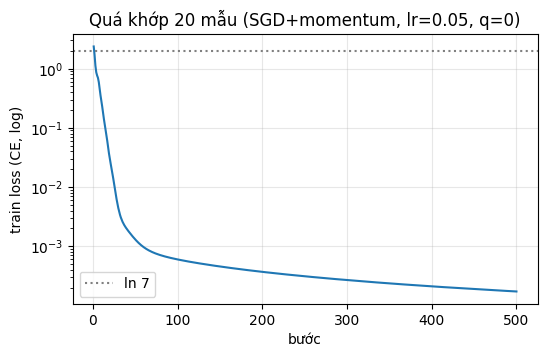

In [6]:
# 1c-2. Quá khớp 20 mẫu: tắt dropout (q = 0), cùng model/hàm loss/optimizer như baseline, 500 bước full-batch
g = torch.Generator().manual_seed(0)
idx20 = torch.randperm(len(X_tr), generator=g)[:20].to(device)
xb20, yb20 = X_tr[idx20], y_tr[idx20]
print("nhãn của 20 mẫu:", yb20.tolist())

set_seed(1)
m20 = MLP((256, 128), dropout=0.0, init="he").to(device)
opt20 = build_optimizer("sgd_momentum", m20.parameters(), lr=0.05)   # lr chỉ dùng cho phép thử này
losses20 = []
for step in range(500):
    m20.train()
    loss = compute_loss(m20(xb20), yb20, "ce")
    opt20.zero_grad(set_to_none=True)
    loss.backward()
    opt20.step()
    losses20.append(loss.item())
acc20 = (predict(m20, xb20) == yb20).float().mean().item()
print(f"loss bước 1 = {losses20[0]:.4f}, bước 100 = {losses20[99]:.2e}, bước 500 = {losses20[-1]:.2e}; accuracy trên 20 mẫu = {acc20:.0%}")
assert losses20[-1] < 1e-2 and acc20 == 1.0

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(range(1, 501), losses20)
ax.axhline(LN7, color="gray", ls=":", label="ln 7")
ax.set(title="Quá khớp 20 mẫu (SGD+momentum, lr=0.05, q=0)", xlabel="bước", ylabel="train loss (CE, log)")
ax.grid(alpha=0.3); ax.legend()
plt.show()

In [7]:
# 1d. Gradient có chảy tới mọi tham số? Một lần forward/backward trên 512 mẫu train
model.train()
model.zero_grad(set_to_none=True)
compute_loss(model(X_tr[:512]), y_tr[:512], "ce").backward()
for i, lin in enumerate((l for l in model.net if isinstance(l, nn.Linear)), 1):
    for name, p in ((f"W{i}", lin.weight), (f"b{i}", lin.bias)):
        assert p.grad is not None and p.grad.norm() > 0, f"{name} không có gradient"
        print(f"{name:3s} {str(tuple(p.shape)):11s} ‖grad‖ = {p.grad.norm().item():.4e}")
print("chuẩn toàn cục:", f"{clip_gradients(model.parameters(), None):.4f}")
model.zero_grad(set_to_none=True)

W1  (256, 54)   ‖grad‖ = 5.0705e-01
b1  (256,)      ‖grad‖ = 3.4224e-01
W2  (128, 256)  ‖grad‖ = 2.0212e+00
b2  (128,)      ‖grad‖ = 4.4387e-01
W3  (7, 128)    ‖grad‖ = 1.9605e+00
b3  (7,)        ‖grad‖ = 5.7246e-01
chuẩn toàn cục: 2.9711


**Nhận xét Part 1:**
- **Model:** 47 879 tham số (assert qua), logits có shape `(8, 7)` và không có softmax trong model. std(W) khớp với He: W1 0,194 so với √(2/54) = 0,192, W2 0,088 so với 0,088, W3 0,123 so với 0,125, bias đều bằng 0. Vậy khởi tạo He thực sự được áp dụng, không phải khởi tạo mặc định của `nn.Linear`.
- **Loss bước 0** đo được là **2,2691** (seed 1), so với ln 7 = 1,9459 thì lệch +0,32. Qua 5 seed, giá trị này dao động từ 1,90 đến 2,31, quanh ln 7. Lý do: ln 7 chỉ đúng khi logits ≈ 0, tức softmax đều trên 7 lớp. He init cho lớp ra Var = 2/128, nên logits có std ≈ 0,53–0,58 (đo bằng `activation_stats`). Khi đó loss bước 0 = E[logsumexp(z)] − E[z_y]: mỗi seed vô tình "ưu ái" một số lớp, và vì nhãn mất cân bằng (lớp 0 và 1 chiếm 85%), loss cao hơn ln 7 khi init bất lợi cho các lớp lớn (seed 1, 4) và thấp hơn khi init có lợi cho chúng (seed 3). **Bằng chứng đây không phải lỗi code:** chỉ cần thu nhỏ W lớp ra ×0,01 (mọi thứ khác giữ nguyên), loss về **1,944–1,948 ≈ ln 7** ở cả 5 seed. Nếu nhãn lệch hay softmax bị áp hai lần thì phép thu nhỏ này không sửa được. Baseline vẫn giữ He cho mọi lớp đúng như quy định. Độ lệch này biến mất rất nhanh: sau epoch 1, val loss đã ≈ 0,48.
- **Quá khớp 20 mẫu** (q = 0, SGD+momentum lr 0,05): loss giảm từ 2,358 xuống 6,0·10⁻⁴ sau 100 bước và 1,7·10⁻⁴ sau 500 bước, accuracy 100%. Như vậy nhãn, hàm loss, `zero_grad` và việc optimizer nhận đủ tham số đều đúng, và mạng đủ năng lực ghi nhớ.
- **Gradient chảy tới mọi tham số:** cả 6 tensor W1, b1, …, b3 đều có ‖grad‖ khác 0, từ 0,34 (b1) đến 2,02 (W2), chuẩn toàn cục 2,97. Không có lớp nào bị "đứt" gradient.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

### 2a. `run_experiment(cfg, data)` (code ở `train.py`)
Mọi lần chạy chỉ khác nhau ở dict `cfg`. Mỗi epoch hàm ghi các giá trị sau:
- `train_loss` đo ở chế độ `eval()` trên **toàn bộ** 371 847 mẫu train, để so trực tiếp được với `val_loss`. Kèm theo `val_loss`, `val_acc`, `val_macro_f1` (cùng định nghĩa với `scripts/evaluate.py`).
- `grad_norm`: chuẩn L2 toàn cục, **đo trước khi clip** (`clip_grad_norm_` trả về giá trị trước khi cắt), lấy trung bình mỗi epoch. Kèm `grad_norm_max` để thấy "gai" và `clip_frac` là tỉ lệ bước bị cắt.
- `epoch_time_s`: chỉ tính phần huấn luyện, có đồng bộ GPU trước khi đo. `peak_mem_MB` chỉ có trên CUDA (CPU/MPS ghi `None`).
- `step0_loss` đo trên val trước bước cập nhật đầu tiên. `best_epoch` là epoch có val loss thấp nhất (đóng vai dừng sớm), và các metric trong `summary` lấy tại epoch đó. Trọng số của epoch này giữ trong `best_state`.
- Cờ `diverged`: nếu loss thành NaN/inf thì dừng ngay và ghi lại.

Một số quyết định: lô cuối nhỏ hơn 512 (371 847 = 726×512 + 135) vẫn được giữ lại. Thứ tự lô chỉ phụ thuộc `seed` (hoán vị sinh trên CPU). Loss luôn tính ở FP32. Sau mỗi lần chạy, kết quả được ghi vào `../results/<exp_id>.json` và ảnh vào `../figures/<exp_id>.png`.

### 2b. Chọn `lr` cho baseline (chỉ bằng val)
Các giá trị thử: 0.003, 0.01, 0.03, 0.1, 0.3 (cách nhau khoảng 3 lần). Mọi thứ khác giữ như baseline (seed 1, 20 epoch). Mỗi lần chạy là một dòng trong bảng (nhóm `hparam`).

**Dự đoán trước khi chạy:** lr = 0.003 quá nhỏ nên sau 20 epoch vẫn chưa hội tụ (val loss còn giảm đều). Với momentum 0,9, bước hiệu dụng là khoảng η/(1−μ) = 10η, nên lr = 0.3 (bước hiệu dụng ≈ 3) có thể làm loss dao động mạnh hoặc phân kỳ. Tôi đoán lr tốt nhất nằm trong khoảng 0.03 đến 0.1.

[lr-sgdm-0.003] step0 2.2691 | best ep 20 val_loss 0.4167 acc 0.8273 f1 0.6754 | 0.34s/epoch


[lr-sgdm-0.01] step0 2.2691 | best ep 19 val_loss 0.3179 acc 0.8717 f1 0.7656 | 0.34s/epoch


[lr-sgdm-0.03] step0 2.2691 | best ep 20 val_loss 0.2631 acc 0.8929 f1 0.8249 | 0.34s/epoch


[lr-sgdm-0.1] step0 2.2691 | best ep 20 val_loss 0.2376 acc 0.9057 f1 0.8560 | 0.34s/epoch


[lr-sgdm-0.3] step0 2.2691 | best ep 20 val_loss 0.2294 acc 0.9094 f1 0.8503 | 0.34s/epoch

    lr   step0 best_ep best_val_loss final_train final_val  val_acc  val_f1 s/epoch
 0.003  2.2691      20        0.4167      0.4104    0.4167   0.8273  0.6754    0.34
  0.01  2.2691      19        0.3179      0.3191    0.3299   0.8717  0.7656    0.34
  0.03  2.2691      20        0.2631      0.2466    0.2631   0.8929  0.8249    0.34
   0.1  2.2691      20        0.2376      0.2144    0.2376   0.9057  0.8560    0.34
   0.3  2.2691      20        0.2294      0.2045    0.2294   0.9094  0.8503    0.34

-> lr chọn cho baseline (val macro-F1 cao nhất): 0.1


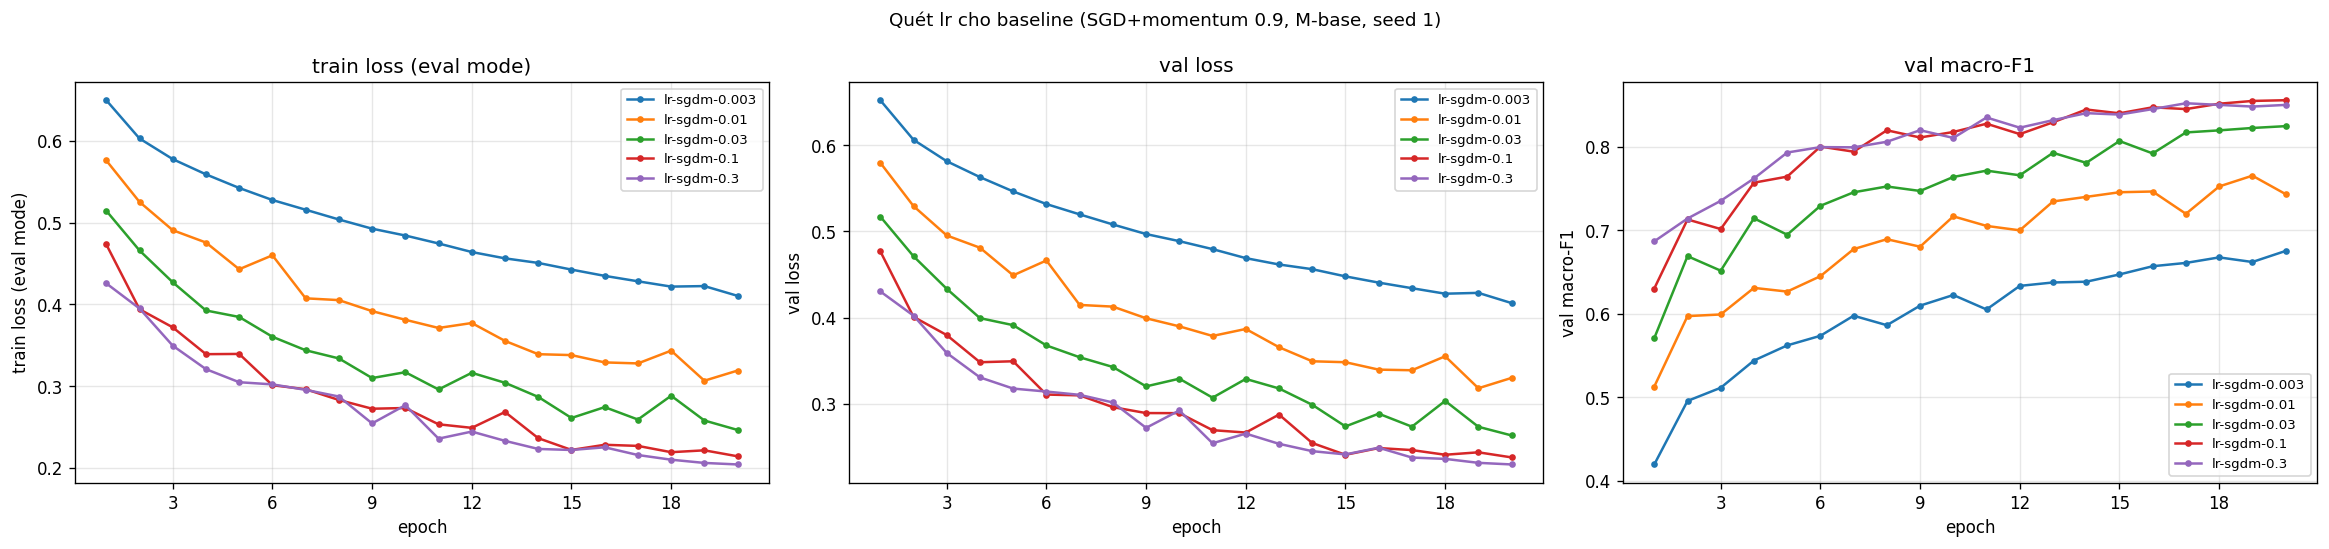

In [8]:
# 2b-1. Quét lr cho SGD+momentum, chọn theo val macro-F1 (chỉ số chính), seed 1, 20 epoch
LRS = [0.003, 0.01, 0.03, 0.1, 0.3]
lr_runs = {}
for lr in LRS:
    r = run_experiment({**DEFAULT_CFG, "lr": lr, "seed": 1, "exp_id": f"lr-sgdm-{lr:g}", "group": "hparam",
                        "description": f"Tìm lr cho baseline: SGD+momentum lr={lr:g}, còn lại như baseline"}, data)
    save_result(r, f"{OUT_DIR}/results")
    plot_run(r, f"{OUT_DIR}/figures/{r['cfg']['exp_id']}.png")
    lr_runs[lr] = r

print(f"\n{'lr':>6s} {'step0':>7s} {'best_ep':>7s} {'best_val_loss':>13s} {'final_train':>11s} {'final_val':>9s} "
      f"{'val_acc':>8s} {'val_f1':>7s} {'s/epoch':>7s}")
for lr, r in lr_runs.items():
    s = r["summary"]
    if s["diverged"] and s["best_epoch"] is None:
        print(f"{lr:>6g}  phân kỳ ngay epoch đầu"); continue
    print(f"{lr:>6g} {s['step0_loss']:>7.4f} {s['best_epoch']:>7d} {s['best_val_loss']:>13.4f} {s['final_train_loss']:>11.4f} "
          f"{s['final_val_loss']:>9.4f} {s['val_acc']:>8.4f} {s['val_macro_f1']:>7.4f} {s['time_per_epoch_s']:>7.2f}"
          + ("  DIVERGED" if s["diverged"] else ""))

ok = {lr: r for lr, r in lr_runs.items() if not r["summary"]["diverged"]}
BEST_LR = max(ok, key=lambda lr: ok[lr]["summary"]["val_macro_f1"])
print(f"\n-> lr chọn cho baseline (val macro-F1 cao nhất): {BEST_LR:g}")
if BEST_LR != DEFAULT_CFG["lr"]:
    print(f"   Lưu ý: khác DEFAULT_CFG['lr'] = {DEFAULT_CFG['lr']:g} trong train.py; notebook dùng BEST_LR, nên cập nhật train.py cho khớp.")

plot_compare(list(lr_runs.values()), ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_lr_sgdm.png",
             title="Quét lr cho baseline (SGD+momentum 0.9, M-base, seed 1)")
display(Image(f"{OUT_DIR}/figures/compare_lr_sgdm.png"))

  ep  1  train 0.4733  val 0.4769  acc 0.7920  f1 0.6304  |g| 0.530  0.3s


  ep  2  train 0.3940  val 0.4008  acc 0.8289  f1 0.7131  |g| 0.562  0.3s


  ep  3  train 0.3720  val 0.3796  acc 0.8439  f1 0.7017  |g| 0.593  0.3s


  ep  4  train 0.3392  val 0.3481  acc 0.8542  f1 0.7572  |g| 0.584  0.3s


  ep  5  train 0.3395  val 0.3492  acc 0.8536  f1 0.7644  |g| 0.579  0.3s


...

  ep 20  train 0.2144  val 0.2376  acc 0.9057  f1 0.8560  |g| 0.558  0.3s
[base-s1] step0 2.2691 | best ep 20 val_loss 0.2376 acc 0.9057 f1 0.8560 | 0.34s/epoch


[base-s2] step0 1.9782 | best ep 20 val_loss 0.2283 acc 0.9090 f1 0.8568 | 0.34s/epoch


[base-s3] step0 1.9005 | best ep 19 val_loss 0.2320 acc 0.9081 f1 0.8583 | 0.34s/epoch


[base-s4] step0 2.3106 | best ep 20 val_loss 0.2293 acc 0.9080 f1 0.8510 | 0.34s/epoch


[base-s5] step0 2.1444 | best ep 20 val_loss 0.2225 acc 0.9116 f1 0.8581 | 0.34s/epoch

tái lập: |Δ val_loss| lớn nhất giữa base-s1 và lr-sgdm-0.1 (cùng cfg, cùng seed) = 0.00e+00


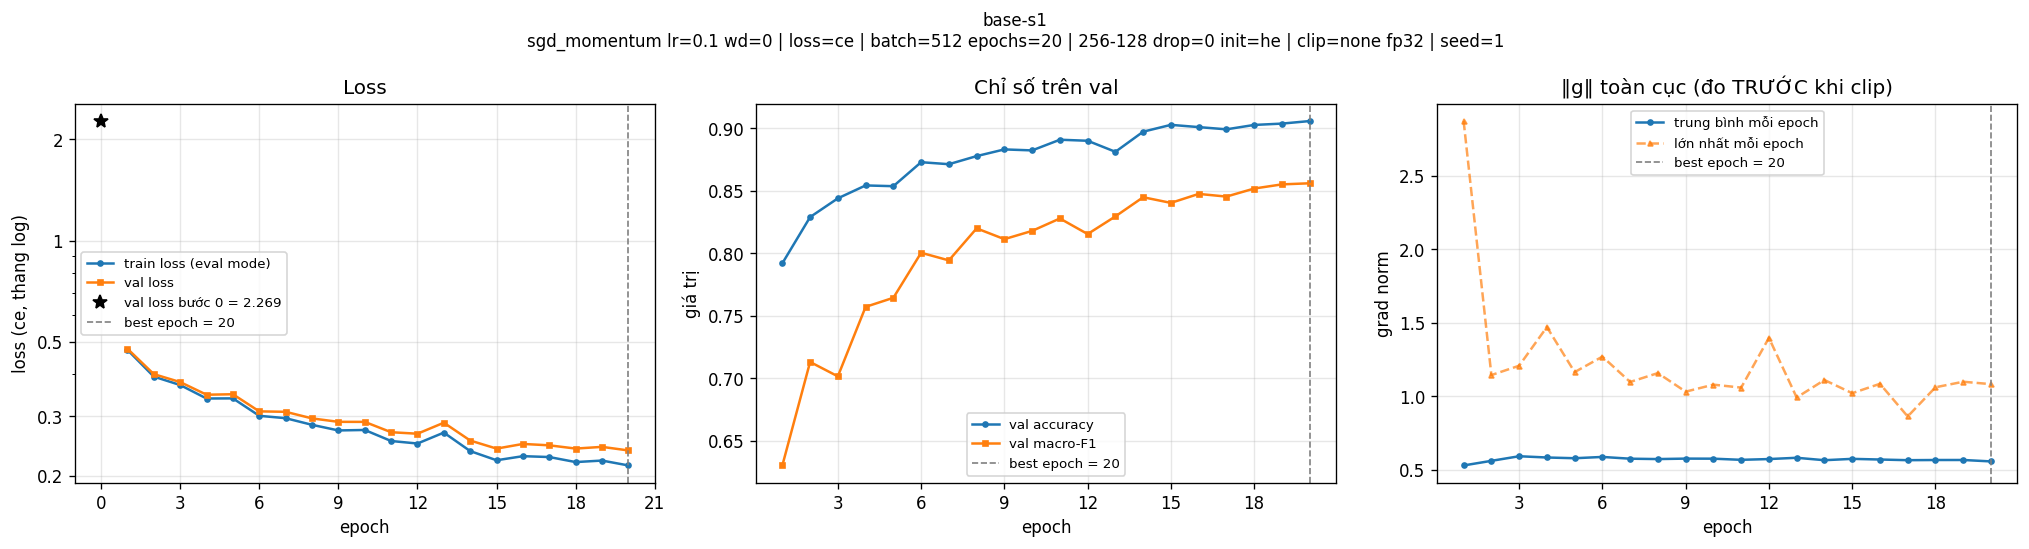

In [9]:
# 2b-2. Baseline với lr đã chọn, 5 seed để đo độ nhiễu (seed đổi cả khởi tạo lẫn thứ tự lô; phép tách val giữ nguyên)
cfg = {**DEFAULT_CFG, "lr": BEST_LR}
SEEDS = [1, 2, 3, 4, 5]
base_runs = []
for s in SEEDS:
    r = run_experiment({**cfg, "seed": s, "exp_id": f"base-s{s}", "description": f"Baseline M-base, seed {s}"},
                       data, verbose=(s == 1))
    save_result(r, f"{OUT_DIR}/results")
    plot_run(r, f"{OUT_DIR}/figures/{r['cfg']['exp_id']}.png")
    base_runs.append(r)

# base-s1 trùng cấu hình và seed với lr-sgdm-<BEST_LR> -> kiểm tra tính tái lập
d = max(abs(a - b) for a, b in zip(base_runs[0]["history"]["val_loss"], lr_runs[BEST_LR]["history"]["val_loss"]))
print(f"\ntái lập: |Δ val_loss| lớn nhất giữa base-s1 và lr-sgdm-{BEST_LR:g} (cùng cfg, cùng seed) = {d:.2e}")
display(Image(f"{OUT_DIR}/figures/base-s1.png"))

  exp_id    best_val_loss       best_epoch final_train_loss   final_val_loss          val_acc     val_macro_f1
 base-s1           0.2376          20.0000           0.2144           0.2376           0.9057           0.8560
 base-s2           0.2283          20.0000           0.2045           0.2283           0.9090           0.8568
 base-s3           0.2320          19.0000           0.2224           0.2469           0.9081           0.8583
 base-s4           0.2293          20.0000           0.2084           0.2293           0.9080           0.8510
 base-s5           0.2225          20.0000           0.2031           0.2225           0.9116           0.8581
 best_val_loss: 0.2299 ± 0.0055   (2σ = 0.0110, min-max = 0.2225-0.2376)
       val_acc: 0.9085 ± 0.0021   (2σ = 0.0043, min-max = 0.9057-0.9116)
  val_macro_f1: 0.8560 ± 0.0030   (2σ = 0.0059, min-max = 0.8510-0.8583)

khoảng cách val − train loss ở epoch cuối: 0.0224 ± 0.0022; best_epoch: [19, 20, 20, 20, 20]
vượt mốc 'đoán đa số'

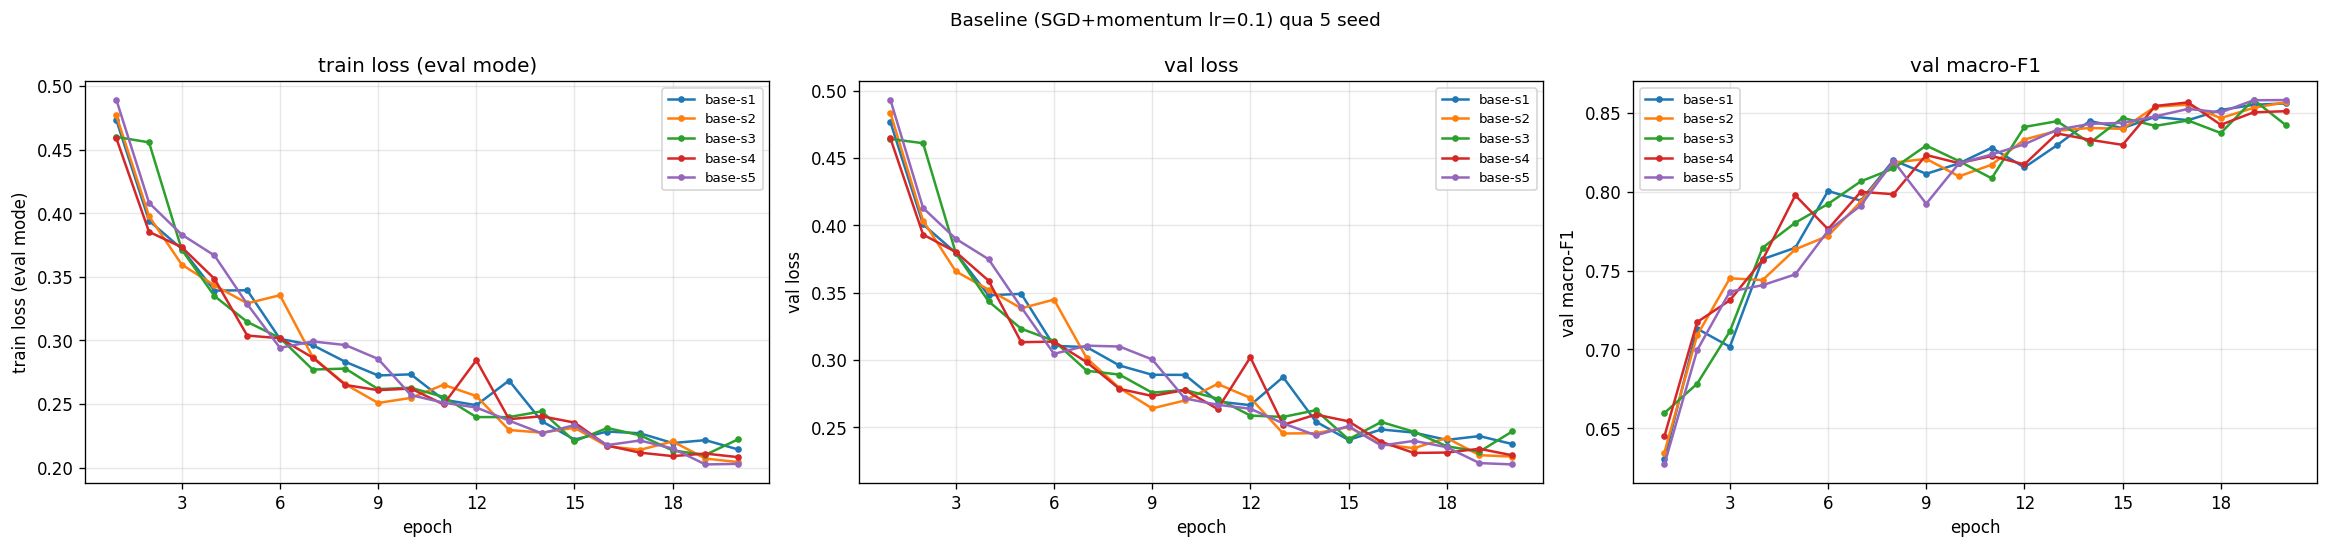

In [10]:
# 2b-3. Độ nhiễu giữa các seed: mean ± std (std mẫu, ddof=1, giống STDEV trong sheet Seeds) và ngưỡng 2σ
cols = ["best_val_loss", "best_epoch", "final_train_loss", "final_val_loss", "val_acc", "val_macro_f1"]
print(f"{'exp_id':>8s} " + " ".join(f"{c:>16s}" for c in cols))
for r in base_runs:
    print(f"{r['cfg']['exp_id']:>8s} " + " ".join(f"{r['summary'][c]:>16.4f}" for c in cols))

NOISE = {}
for c in ["best_val_loss", "val_acc", "val_macro_f1"]:
    v = np.array([r["summary"][c] for r in base_runs])
    NOISE[c] = dict(mean=v.mean(), std=v.std(ddof=1), two_sigma=2 * v.std(ddof=1))
    print(f"{c:>14s}: {v.mean():.4f} ± {v.std(ddof=1):.4f}   (2σ = {2 * v.std(ddof=1):.4f}, min-max = {v.min():.4f}-{v.max():.4f})")
gap = np.array([r["summary"]["final_val_loss"] - r["summary"]["final_train_loss"] for r in base_runs])
print(f"\nkhoảng cách val − train loss ở epoch cuối: {gap.mean():.4f} ± {gap.std(ddof=1):.4f}; "
      f"best_epoch: {sorted(r['summary']['best_epoch'] for r in base_runs)}")
print(f"vượt mốc 'đoán đa số'? val_acc thấp nhất {min(r['summary']['val_acc'] for r in base_runs):.4f} > {MAJ_ACC:.4f}")
gn = np.array([r["history"]["grad_norm"] for r in base_runs])
gmax = np.array([r["history"]["grad_norm_max"] for r in base_runs])
print(f"grad_norm baseline (trước clip): trung bình epoch 1 = {gn[:, 0].mean():.3f}, epoch 20 = {gn[:, -1].mean():.3f}; "
      f"lớn nhất mọi bước = {gmax.max():.3f}  (tham khảo khi chọn c cho clipping ở Part 3)")

plot_compare(base_runs, ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_baseline_seeds.png",
             title=f"Baseline (SGD+momentum lr={BEST_LR:g}) qua {len(SEEDS)} seed")
display(Image(f"{OUT_DIR}/figures/compare_baseline_seeds.png"))

**Nhận xét chọn lr (nhóm `hparam`, so với dự đoán):**
- lr = 0,003 và 0,01 **chưa hội tụ** sau 20 epoch: val loss còn giảm đều (0,417 và 0,318–0,330), val macro-F1 chỉ đạt 0,675 và 0,766. Điều này khớp dự đoán: bước nhỏ nên 20 epoch (≈ 14 500 bước) là chưa đủ.
- lr = 0,03 đạt 0,825. lr = 0,1 đạt val macro-F1 **cao nhất, 0,8560** (val loss 0,2376). lr = 0,3 có val loss **thấp nhất (0,2294)** nhưng macro-F1 là 0,8503.
- **Dự đoán sai ở lr = 0,3:** tôi dự đoán loss sẽ dao động hoặc phân kỳ, nhưng thực tế không phân kỳ và đường cong còn mượt như lr = 0,1. Phỏng đoán (chưa kiểm chứng): mạng nông, đầu vào đã chuẩn hoá, và ‖g‖ trung bình ở lr = 0,3 chỉ 0,34–0,40 (đo được), nên bước hiệu dụng ≈ 3 vẫn nằm trong vùng ổn định. Ngưỡng phân kỳ có lẽ cao hơn (chưa thử lr ≥ 1 với SGD+momentum).
- **lr = 0,1 và 0,3 chưa phân biệt được:** chênh lệch val macro-F1 là 0,0057, nhỏ hơn 2σ_seed = 0,0059 (đo bên dưới), và val loss lại xếp hạng ngược chiều. Tôi chọn **lr = 0,1** theo tiêu chí đặt trước khi chạy (val macro-F1 cao nhất, chỉ số chính), cũng là lựa chọn thận trọng hơn về ổn định. Hạn chế: mỗi lr chỉ chạy 1 seed và chưa thử lr > 0,3.

**Nhận xét baseline** (M-base, SGD+momentum 0,9, lr 0,1, He, CE, batch 512, 20 epoch, 5 seed):
- **Vượt xa mốc "đoán đa số":** val accuracy **0,9085 ± 0,0021** so với 0,4876; val macro-F1 **0,8560 ± 0,0030** so với 0,0936.
- **Hình dạng đường cong:** train loss và val loss (cả hai đo ở eval mode) giảm gần như song song. Khoảng cách val − train ở epoch cuối chỉ 0,022 ± 0,002, và `best_epoch` = 19–20 ở cả 5 seed. Mô hình **còn đang học và chưa quá khớp**: thiếu khớp theo thời gian huấn luyện, không phải theo dữ liệu. Huấn luyện lâu hơn, giảm lr dần hoặc dùng mạng rộng/sâu hơn có khả năng cải thiện. Dropout khó giúp ích vì chưa có quá khớp để chữa. Đường cong có vài "gai" ngắn (ví dụ epoch 13 của s1, epoch 12 của s4): đó là nhiễu của SGD với lr lớn, và đường cong hồi phục ngay ở epoch kế tiếp. Riêng s3 có gai đúng ở epoch 20, nên `best_epoch` của s3 là 19.
- **Độ nhiễu seed** (5 seed, std mẫu): val macro-F1 σ = 0,0030 nên **2σ = 0,0059**; val accuracy 2σ = 0,0043; best val loss 2σ = 0,0110. Ở Part 3, mọi chênh lệch nhỏ hơn các ngưỡng này **không được coi là bằng chứng**. Với 5 seed, σ vẫn chỉ là ước lượng thô. Macro-F1 nhiễu hơn accuracy (tương đối) vì lớp hiếm có ít mẫu trong val (lớp 3 chỉ ≈ 440 mẫu), nên vài mẫu đúng/sai cũng làm F1 của lớp đó dao động.
- **`grad_norm` (trước clip):** trung bình mỗi epoch ổn định quanh 0,50–0,59; giá trị lớn nhất mỗi lần chạy là 2,4–2,9 và ở cả 5 seed đều rơi vào epoch 1. Đây là căn cứ chọn ngưỡng c khi thí nghiệm clipping.
- **Tái lập:** `base-s1` trùng cấu hình và seed với `lr-sgdm-0.1`, và cho kết quả giống hệt (|Δ val_loss| = 0). Trên CPU pipeline tất định; trên GPU có thể lệch rất nhỏ.
- **Thời gian:** ≈ 0,34 s/epoch trên CPU (4 luồng). `peak_mem_MB` không đo được trên CPU (chỉ có trên CUDA), sẽ ghi vào `notes` của bảng.

## Part 3 — Thí nghiệm: chủ đề **bộ tối ưu hoá (`optimizer`)**

**Vì sao chọn chủ đề này (căn cứ trên số đo ở Part 2):**
- **Chẩn đoán baseline:** train loss ≈ val loss (khoảng cách 0,022), `best_epoch` = 19–20 ở cả 5 seed, val loss vẫn đang giảm. Nút thắt hiện tại là **tối ưu hoá chưa đi đủ xa trong ngân sách 20 epoch** (thiếu khớp theo thời gian). Baseline không quá khớp và cũng không mất ổn định.
- **Đối chiếu bảng triệu chứng:** các chủ đề còn lại chữa những bệnh baseline không có. Dropout chữa quá khớp (chưa có). Clipping chữa gradient bùng nổ (‖g‖ chỉ 0,5–2,9, không có gai lớn). Mixed precision chỉ đổi tốc độ/bộ nhớ, không đổi điều mô hình học được. Khởi tạo He đã cho gradient chảy tới mọi lớp (Part 1d). Đổi CE sang MSE chỉ làm gradient yếu đi khi dự đoán sai nặng.
- **Bộ tối ưu (cùng với lr của nó)** quyết định mỗi bước cập nhật đi theo hướng nào và xa bao nhiêu, nên tác động thẳng vào nút thắt trên. Đây cũng là chủ đề GUIDE ưu tiên đầu tiên sau baseline. So bộ tối ưu chỉ có nghĩa khi **mỗi bộ được chỉnh lr riêng**, vì vậy phần này gồm cả quét lr.

**Thiết kế (công bằng):** giữ nguyên mọi thứ của baseline (M-base, He, CE, batch 512, 20 epoch, không dropout/clip, FP32, cùng phép tách val). Chỉ đổi bộ tối ưu và lr của nó.

| Bộ tối ưu | Tham số | Lưới lr (seed 1) |
|---|---|---|
| SGD | momentum = 0 | 0.1, 0.3, 1, 3 |
| SGD+momentum | μ = 0,9 | 0.003, 0.01, 0.03, 0.1, 0.3 (đã chạy ở Part 2: `lr-sgdm-*`) |
| Adam | β = (0,9; 0,999), ε = 1e-8, wd = 0 | 1e-4, 3e-4, 1e-3, 3e-3, 1e-2 |
| AdamW | như Adam, wd = 0,01 (tách riêng) | 1e-4, 3e-4, 1e-3, 3e-3, 1e-2 |

Lưới của SGD được dịch lên khoảng ×10 so với SGD+momentum, vì bước hiệu dụng của momentum là η/(1−μ) = 10η.

**Quy trình và luật chọn (đặt trước khi chạy):**
1. Quét lr bằng seed 1, chọn lr tốt nhất của từng bộ theo **val macro-F1** (cùng tiêu chí với Part 2).
2. Chạy lr tốt nhất của mỗi bộ thêm seed 2–5 (SGD+momentum dùng luôn `base-s1..s5`), để so **ở lr tốt nhất của mỗi bộ** có tính độ nhiễu.
3. **Cấu hình cuối cùng** là bộ tối ưu có val macro-F1 **trung bình 5 seed** cao nhất. Mô hình nộp là **seed 1** của cấu hình đó (cố định trước, không chọn theo eval).
4. Kiểm chứng phụ: AdamW với wd = 0 phải trùng Adam.

In [11]:
# Hàm phụ cho Part 3: chạy + lưu JSON + lưu ảnh; in bảng; chọn lr tốt nhất theo val macro-F1
def run_and_save(c, verbose=False):
    r = run_experiment(c, data, verbose=verbose)
    save_result(r, f"{OUT_DIR}/results")
    plot_run(r, f"{OUT_DIR}/figures/{r['cfg']['exp_id']}.png")
    return r

def show_runs(runs):
    print(f"{'exp_id':>26s} {'lr':>7s} {'best_ep':>7s} {'best_val_loss':>13s} {'val_acc':>8s} {'val_f1':>7s} "
          f"{'Δf1 vs base':>11s} {'s/epoch':>7s}")
    for r in runs:
        s = r["summary"]
        if s["best_epoch"] is None:
            print(f"{r['cfg']['exp_id']:>26s} {r['cfg']['lr']:>7g}   phân kỳ ngay epoch đầu")
            continue
        d = s["val_macro_f1"] - NOISE["val_macro_f1"]["mean"]   # so với trung bình 5 seed baseline
        print(f"{r['cfg']['exp_id']:>26s} {r['cfg']['lr']:>7g} {s['best_epoch']:>7d} {s['best_val_loss']:>13.4f} "
              f"{s['val_acc']:>8.4f} {s['val_macro_f1']:>7.4f} {d:>+11.4f} {s['time_per_epoch_s']:>7.2f}"
              + ("  DIVERGED" if s["diverged"] else ""))

def best_lr(runs: dict) -> float:
    ok = {lr: r for lr, r in runs.items() if not r["summary"]["diverged"]}
    lr = max(ok, key=lambda k: ok[k]["summary"]["val_macro_f1"])
    if lr in (min(runs), max(runs)):
        print(f"  CẢNH BÁO: lr tốt nhất {lr:g} nằm ở biên lưới -> nên mở rộng lưới")
    return lr

OPT_LABEL = {"sgd_momentum": "SGD+momentum", "sgd": "SGD", "adam": "Adam", "adamw": "AdamW"}
sweeps = {"sgd_momentum": lr_runs}   # SGD+momentum đã quét ở Part 2 (lr-sgdm-*), seed 1
print(f"baseline (5 seed): val macro-F1 = {NOISE['val_macro_f1']['mean']:.4f}, ngưỡng nhiễu 2σ = {NOISE['val_macro_f1']['two_sigma']:.4f}")

baseline (5 seed): val macro-F1 = 0.8560, ngưỡng nhiễu 2σ = 0.0059


### Thí nghiệm 3.1 — SGD không momentum (`opt-sgd-lr*`) — chủ đề `optimizer`
**Dự đoán trước (viết TRƯỚC khi chạy):** không có momentum thì mỗi bước chỉ đi theo gradient của lô hiện tại. Ở cùng lr, bước đi ngắn hơn SGD+momentum khoảng 10 lần, nên lr tốt nhất của SGD sẽ cao hơn khoảng 10 lần (≈ 1). Với lr nhỏ, SGD có lr η/(1−μ) gần tương đương SGD+momentum có lr η, nên ở lr tốt nhất của mình SGD sẽ đạt **xấp xỉ SGD+momentum** (chênh trong khoảng nhiễu 2σ hoặc kém hơn một chút). lr = 3 có thể dao động mạnh hoặc phân kỳ.

In [12]:
# 3.1 SGD (momentum = 0): chỉ đổi bộ tối ưu và lr, mọi thứ khác như baseline (cfg), seed 1
sweeps["sgd"] = {lr: run_and_save({**cfg, "optimizer": "sgd", "momentum": 0.0, "lr": lr, "seed": 1, "group": "optimizer",
                                   "exp_id": f"opt-sgd-lr{lr:g}", "description": f"SGD không momentum, lr={lr:g}"})
                 for lr in [0.1, 0.3, 1.0, 3.0]}
print()
show_runs(sweeps["sgd"].values())
print("-> lr tốt nhất của SGD:", best_lr(sweeps["sgd"]))

[opt-sgd-lr0.1] step0 2.2691 | best ep 18 val_loss 0.3444 acc 0.8564 f1 0.7398 | 0.33s/epoch


[opt-sgd-lr0.3] step0 2.2691 | best ep 16 val_loss 0.2913 acc 0.8793 f1 0.7975 | 0.33s/epoch


[opt-sgd-lr1] step0 2.2691 | best ep 16 val_loss 0.2665 acc 0.8928 f1 0.7994 | 0.33s/epoch


[opt-sgd-lr3] step0 2.2691 | best ep 16 val_loss 0.3547 acc 0.8588 f1 0.6280 | 0.33s/epoch

                    exp_id      lr best_ep best_val_loss  val_acc  val_f1 Δf1 vs base s/epoch
             opt-sgd-lr0.1     0.1      18        0.3444   0.8564  0.7398     -0.1162    0.33
             opt-sgd-lr0.3     0.3      16        0.2913   0.8793  0.7975     -0.0585    0.33
               opt-sgd-lr1       1      16        0.2665   0.8928  0.7994     -0.0566    0.33
               opt-sgd-lr3       3      16        0.3547   0.8588  0.6280     -0.2280    0.33
-> lr tốt nhất của SGD: 1.0


**Đối chiếu sau khi chạy (3.1):** 
- lr tốt nhất của SGD là **1** (val macro-F1 0,7994 ở seed 1), đúng như dự đoán: cao hơn SGD+momentum khoảng 10 lần. lr = 3 không phân kỳ (không NaN), nhưng ‖g‖ có một gai tới **227** ngay epoch 1 (baseline lớn nhất chỉ 2,9), val loss sau epoch 1 là 1,12, và macro-F1 chỉ đạt 0,628. Phần "dao động mạnh" của dự đoán là đúng (`opt-sgd-lr3.png`).
- **Dự đoán sai ở điểm chính:** ở lr tốt nhất của mình, SGD **kém rõ rệt** so với SGD+momentum chứ không xấp xỉ. 5 seed cho **0,8315 ± 0,0203** so với 0,8560 ± 0,0030 (Δ = −0,0245, vượt 2σ = 0,0059). Độ lệch chuẩn giữa các seed lớn gấp khoảng 7 lần baseline.
- **Cơ chế:** phép "tương đương" η_SGD = η/(1−μ) chỉ đúng cho bước đi **trung bình**. Giả sử nhiễu gradient của lô độc lập giữa các bước với phương sai σ². Khi đó cập nhật của SGD có phương sai (10η)²σ² = 100η²σ², còn momentum cộng dồn gradient với trọng số μᵏ nên phương sai chỉ là η²σ²/(1−μ²) ≈ 5,3η²σ². Nói cách khác, momentum là bộ lọc thông thấp: cùng tốc độ trung bình nhưng nhiễu ít hơn khoảng 19 lần. Số đo khớp với giải thích này. Ở lr = 1, val loss của SGD tăng trở lại ở 5–10/19 epoch (SGD+momentum: 3–6). Macro-F1 dao động giữa các epoch 11–20 với std 0,014–0,029 (SGD+momentum: 0,011–0,013). ‖g‖ lớn nhất mỗi lần chạy là 5,6–10 (SGD+momentum: ≤ 2,9). Xem đường răng cưa màu cam trong `compare_optimizer.png`. Vì `best_epoch` được chọn theo val loss, điểm dừng rơi vào một vị trí ngẫu nhiên trên đường răng cưa, dẫn đến phương sai giữa các seed lớn.
- Seed 1 của SGD tình cờ là seed tệ nhất (0,7994, trong khi seed 2–5 trung bình 0,8395). Với một bộ tối ưu nhiễu như vậy, chọn lr bằng một seed là không đáng tin. Đây là một hạn chế của thiết kế.

### Thí nghiệm 3.2 — Adam (`opt-adam-lr*`) — chủ đề `optimizer`
**Dự đoán trước (viết TRƯỚC khi chạy):** Adam chia bước của từng tham số cho √v̂ (độ lớn gradient gần đây của chính tham số đó). Ở dữ liệu này, 44/54 cột đầu vào là one-hot thưa, nhiều `Soil_Type` rất hiếm, nên trọng số nối với các cột hiếm nhận gradient vừa nhỏ vừa thưa thớt. SGD cập nhật chúng rất chậm, còn Adam chuẩn hoá lại nên chúng được học nhanh hơn. Tôi dự đoán:
- lr tốt nhất nằm khoảng 1e-3 đến 3e-3; lr 1e-4 quá chậm, lr 1e-2 có thể dao động;
- Adam hội tụ nhanh hơn rõ ở các epoch đầu;
- val macro-F1 cao hơn baseline **vượt 2σ (0,0059)**, khoảng +0,01 đến +0,03, chủ yếu nhờ các lớp hiếm.

In [13]:
# 3.2 Adam (betas=(0.9, 0.999), eps=1e-8, weight_decay=0), seed 1
sweeps["adam"] = {lr: run_and_save({**cfg, "optimizer": "adam", "lr": lr, "seed": 1, "group": "optimizer",
                                    "exp_id": f"opt-adam-lr{lr:g}", "description": f"Adam (betas=(0.9,0.999), eps=1e-8), lr={lr:g}"})
                  for lr in [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]}
print()
show_runs(sweeps["adam"].values())
print("-> lr tốt nhất của Adam:", best_lr(sweeps["adam"]))

[opt-adam-lr0.0001] step0 2.2691 | best ep 20 val_loss 0.4002 acc 0.8344 f1 0.7153 | 0.40s/epoch


[opt-adam-lr0.0003] step0 2.2691 | best ep 20 val_loss 0.3090 acc 0.8749 f1 0.7939 | 0.41s/epoch


[opt-adam-lr0.001] step0 2.2691 | best ep 18 val_loss 0.2441 acc 0.9013 f1 0.8427 | 0.40s/epoch


[opt-adam-lr0.003] step0 2.2691 | best ep 20 val_loss 0.2120 acc 0.9153 f1 0.8753 | 0.40s/epoch


[opt-adam-lr0.01] step0 2.2691 | best ep 19 val_loss 0.2158 acc 0.9144 f1 0.8662 | 0.40s/epoch

                    exp_id      lr best_ep best_val_loss  val_acc  val_f1 Δf1 vs base s/epoch
         opt-adam-lr0.0001  0.0001      20        0.4002   0.8344  0.7153     -0.1407    0.40
         opt-adam-lr0.0003  0.0003      20        0.3090   0.8749  0.7939     -0.0621    0.41
          opt-adam-lr0.001   0.001      18        0.2441   0.9013  0.8427     -0.0133    0.40
          opt-adam-lr0.003   0.003      20        0.2120   0.9153  0.8753     +0.0193    0.40
           opt-adam-lr0.01    0.01      19        0.2158   0.9144  0.8662     +0.0102    0.40
-> lr tốt nhất của Adam: 0.003


**Đối chiếu sau khi chạy (3.2):** 
- lr tốt nhất là **3e-3** (val macro-F1 0,8753 ở seed 1), nằm trong khoảng dự đoán. lr 1e-4 và 3e-4 quá chậm (0,715 và 0,794, val loss vẫn giảm đều). Khác dự đoán: lr 1e-2 vẫn tốt (0,866) chứ không dao động. Adam ít nhạy với lr ở phía trên hơn tôi nghĩ.
- **Hội tụ nhanh hơn**, đúng dự đoán. Val loss của Adam (3e-3) so với baseline seed 1 ở epoch 1/5/10/20 là 0,433/0,295/0,249/0,212 so với 0,477/0,349/0,289/0,238. Adam đạt mức val loss cuối của baseline (0,2376) ngay ở **epoch 12**.
- **5 seed:** **0,8705 ± 0,0046** so với baseline 0,8560 ± 0,0030, tức Δ = **+0,0145 > 2σ (0,0059)**. Chênh lệch **có ý nghĩa** và nằm trong khoảng +0,01–0,03 đã dự đoán. Val accuracy là 0,9161 ± 0,0012 so với 0,9085 ± 0,0021 (Δ = +0,0076 > 2σ_acc = 0,0043).
- **Cơ chế:** (1) Adam chia bước cho √v̂ của từng tham số, nên trọng số nối với các cột one-hot hiếm (gradient nhỏ và thưa) nhận bước tương đối lớn hơn so với SGD. Bằng chứng gián tiếp trên val ở mục 3.5: các lớp hiếm cải thiện nhiều nhất. Tôi chưa đo trực tiếp độ lớn cập nhật của từng nhóm trọng số, nên đây là giải thích có căn cứ chứ chưa phải điều đã chứng minh. (2) Momentum bậc một (β₁ = 0,9) của Adam cũng làm mượt nhiễu như ở 3.1: val loss của Adam chỉ tăng trở lại ở 3–7/19 epoch, và F1 giữa các epoch dao động với std 0,007–0,011.
- Mô hình vẫn chưa hội tụ: `best_epoch` = 19–20 ở cả 5 seed. Khoảng cách val − train ở epoch cuối ≈ 0,028, lớn hơn baseline (0,022) một chút nhưng chưa phải quá khớp.

### Thí nghiệm 3.3 — AdamW, weight decay = 0,01 (`opt-adamw-wd0.01-lr*`) — chủ đề `optimizer`
**Dự đoán trước (viết TRƯỚC khi chạy):** AdamW khác Adam đúng một điểm: suy giảm trọng số được **tách riêng** khỏi gradient, `w ← w − ηλw − η·m̂/(√v̂+ε)`. Mô hình đang thiếu khớp, nên thêm chính quy hoá không có gì để chữa. Với η ≈ 1e-3 và λ = 0,01, mỗi bước chỉ co trọng số theo hệ số (1 − 1e-5). Dự đoán: AdamW ≈ Adam (|Δ| < 2σ), có thể kém hơn rất ít. **Kiểm chứng:** AdamW với λ = 0 dùng đúng công thức cập nhật của Adam, nên phải cho kết quả **trùng hệt** Adam (cùng lr, cùng seed).

In [14]:
# 3.3 AdamW (weight_decay=0.01, suy giảm tách riêng), seed 1
sweeps["adamw"] = {lr: run_and_save({**cfg, "optimizer": "adamw", "weight_decay": 0.01, "lr": lr, "seed": 1, "group": "optimizer",
                                     "exp_id": f"opt-adamw-wd0.01-lr{lr:g}",
                                     "description": f"AdamW (betas=(0.9,0.999), eps=1e-8, wd=0.01), lr={lr:g}"})
                   for lr in [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]}
print()
show_runs(sweeps["adamw"].values())
print("-> lr tốt nhất của AdamW:", best_lr(sweeps["adamw"]))

# Kiểm chứng: AdamW với weight_decay = 0 ở lr tốt nhất của Adam phải trùng Adam (cùng lr, cùng seed)
lr_a = best_lr(sweeps["adam"])
chk = run_and_save({**cfg, "optimizer": "adamw", "weight_decay": 0.0, "lr": lr_a, "seed": 1, "group": "optimizer",
                    "exp_id": f"opt-adamw-wd0-lr{lr_a:g}",
                    "description": f"Kiểm chứng: AdamW wd=0, lr={lr_a:g} (phải trùng Adam cùng lr, cùng seed)"})
d = max(abs(a - b) for a, b in zip(chk["history"]["val_loss"], sweeps["adam"][lr_a]["history"]["val_loss"]))
print(f"AdamW(wd=0) so với Adam, lr={lr_a:g}, seed 1: |Δ val_loss| lớn nhất qua 20 epoch = {d:.2e}")

[opt-adamw-wd0.01-lr0.0001] step0 2.2691 | best ep 20 val_loss 0.4011 acc 0.8341 f1 0.7148 | 0.41s/epoch


[opt-adamw-wd0.01-lr0.0003] step0 2.2691 | best ep 20 val_loss 0.3104 acc 0.8745 f1 0.7918 | 0.40s/epoch


[opt-adamw-wd0.01-lr0.001] step0 2.2691 | best ep 18 val_loss 0.2476 acc 0.9005 f1 0.8393 | 0.41s/epoch


[opt-adamw-wd0.01-lr0.003] step0 2.2691 | best ep 20 val_loss 0.2128 acc 0.9141 f1 0.8733 | 0.41s/epoch


[opt-adamw-wd0.01-lr0.01] step0 2.2691 | best ep 20 val_loss 0.2255 acc 0.9099 f1 0.8585 | 0.41s/epoch

                    exp_id      lr best_ep best_val_loss  val_acc  val_f1 Δf1 vs base s/epoch
 opt-adamw-wd0.01-lr0.0001  0.0001      20        0.4011   0.8341  0.7148     -0.1413    0.41
 opt-adamw-wd0.01-lr0.0003  0.0003      20        0.3104   0.8745  0.7918     -0.0642    0.40
  opt-adamw-wd0.01-lr0.001   0.001      18        0.2476   0.9005  0.8393     -0.0168    0.41
  opt-adamw-wd0.01-lr0.003   0.003      20        0.2128   0.9141  0.8733     +0.0173    0.41
   opt-adamw-wd0.01-lr0.01    0.01      20        0.2255   0.9099  0.8585     +0.0024    0.41
-> lr tốt nhất của AdamW: 0.003


[opt-adamw-wd0-lr0.003] step0 2.2691 | best ep 20 val_loss 0.2120 acc 0.9153 f1 0.8753 | 0.41s/epoch
AdamW(wd=0) so với Adam, lr=0.003, seed 1: |Δ val_loss| lớn nhất qua 20 epoch = 0.00e+00


**Đối chiếu sau khi chạy (3.3):** 
- Đúng dự đoán: AdamW (wd = 0,01) ≈ Adam. Ở lr tốt nhất chung là 3e-3, 5 seed cho **0,8673 ± 0,0056** so với Adam 0,8705 ± 0,0046, Δ = −0,0032 < 2σ, nên **không phân biệt được**.
- Một xu hướng nhất quán: ở cả 5 lr của lưới, AdamW đều thấp hơn Adam một chút (−0,0005 đến −0,0077). Từng chênh lệch đều nằm trong nhiễu, trừ lr = 1e-2 (−0,0077), nên chỉ nói được là "hơi kém". Train loss cuối của AdamW cao hơn Adam ở **cả 5 seed** (trung bình 0,194 so với 0,186). Điều này phù hợp với cơ chế: weight decay là chính quy hoá, mà mô hình đang thiếu khớp, nên kéo trọng số về 0 chỉ làm giảm nhẹ khả năng khớp chứ không có quá khớp nào để chữa.
- **Kiểm chứng AdamW wd = 0 ≡ Adam:** |Δ val_loss| = **0 tuyệt đối** qua 20 epoch (`opt-adamw-wd0-lr0.003` so với `opt-adam-lr0.003`). Điều này đúng với công thức: khi λ = 0, AdamW và Adam là cùng một phép cập nhật. Khác biệt duy nhất giữa hai bộ là cách áp dụng weight decay.

### Thí nghiệm 3.4 — So các bộ tối ưu ở lr tốt nhất của mỗi bộ, 5 seed
**Dự đoán trước (viết TRƯỚC khi chạy):** thứ hạng theo val macro-F1 trung bình là Adam ≈ AdamW > SGD+momentum ≈ SGD. Adam/AdamW vượt baseline quá 2σ; SGD và SGD+momentum chênh nhau dưới 2σ. Seed 1 đã được dùng để chọn lr nên có thể hơi lạc quan (winner's curse); vì vậy bảng in thêm trung bình riêng seed 2–5 làm ước lượng không thiên lệch.

[opt-sgd-lr1-s2] step0 1.9782 | best ep 20 val_loss 0.2458 acc 0.9004 f1 0.8380 | 0.33s/epoch


[opt-sgd-lr1-s3] step0 1.9005 | best ep 20 val_loss 0.2366 acc 0.9056 f1 0.8454 | 0.33s/epoch


[opt-sgd-lr1-s4] step0 2.3106 | best ep 18 val_loss 0.2601 acc 0.8966 f1 0.8498 | 0.33s/epoch


[opt-sgd-lr1-s5] step0 2.1444 | best ep 18 val_loss 0.2436 acc 0.9027 f1 0.8249 | 0.32s/epoch


[opt-adam-lr0.003-s2] step0 1.9782 | best ep 19 val_loss 0.2112 acc 0.9161 f1 0.8665 | 0.40s/epoch


...

[opt-adam-lr0.003-s5] step0 2.1444 | best ep 20 val_loss 0.2168 acc 0.9146 f1 0.8683 | 0.41s/epoch


[opt-adamw-wd0.01-lr0.003-s2] step0 1.9782 | best ep 19 val_loss 0.2175 acc 0.9142 f1 0.8681 | 0.41s/epoch


[opt-adamw-wd0.01-lr0.003-s3] step0 1.9005 | best ep 18 val_loss 0.2203 acc 0.9118 f1 0.8592 | 0.41s/epoch


[opt-adamw-wd0.01-lr0.003-s4] step0 2.3106 | best ep 19 val_loss 0.2133 acc 0.9145 f1 0.8647 | 0.41s/epoch


[opt-adamw-wd0.01-lr0.003-s5] step0 2.1444 | best ep 20 val_loss 0.2148 acc 0.9137 f1 0.8710 | 0.42s/epoch

    bộ tối ưu     lr*  val_f1 TB±std (5 seed) TB seed 2-5   val_acc TB±std best_val_loss   best_ep s/epoch Δf1 vs base  > 2σ?
 SGD+momentum     0.1         0.8560 ± 0.0030      0.8561    0.9085 ± 0.0021        0.2299   19-20      0.34     +0.0000      —
          SGD       1         0.8315 ± 0.0203      0.8395    0.8996 ± 0.0051        0.2505   16-20      0.33     -0.0245     Có
         Adam   0.003         0.8705 ± 0.0046      0.8693    0.9161 ± 0.0012        0.2112   19-20      0.40     +0.0145     Có
        AdamW   0.003         0.8673 ± 0.0056      0.8658    0.9136 ± 0.0011        0.2157   18-20      0.41     +0.0112     Có

-> CẤU HÌNH CUỐI CÙNG (chọn bằng val): Adam lr=0.003; mô hình nộp = opt-adam-lr0.003 (seed 1)


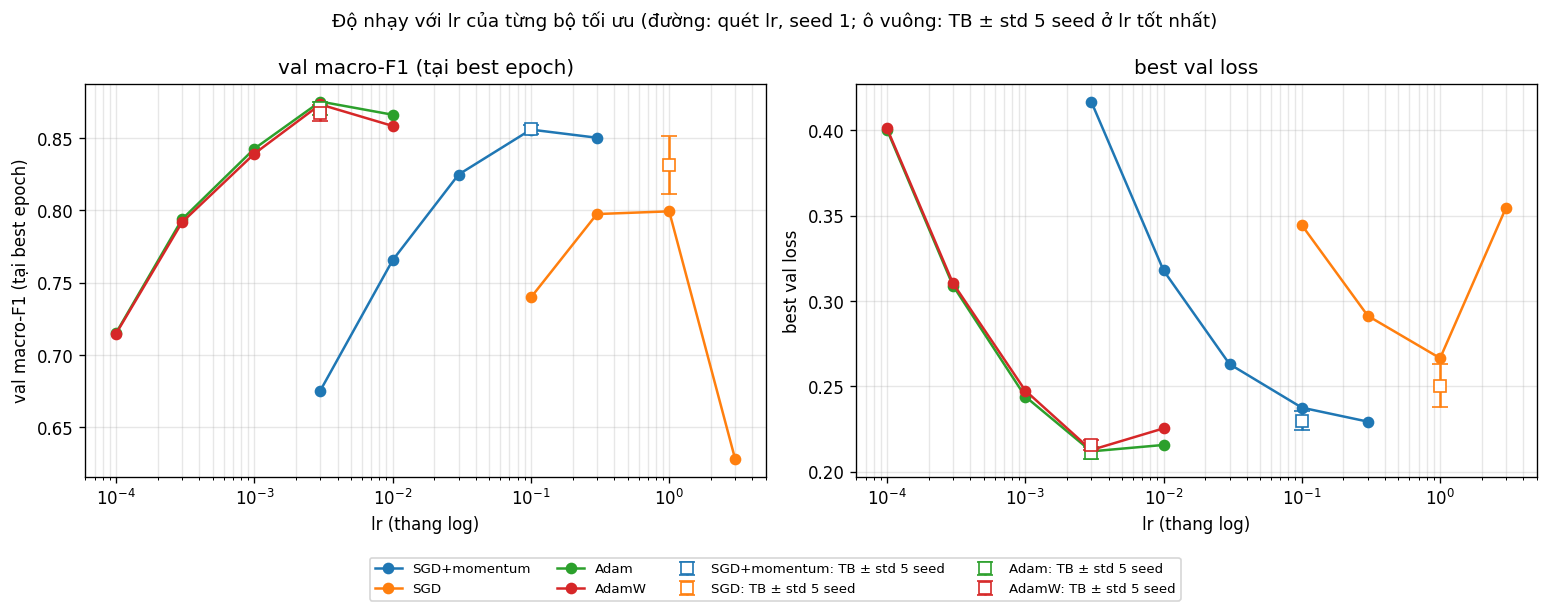

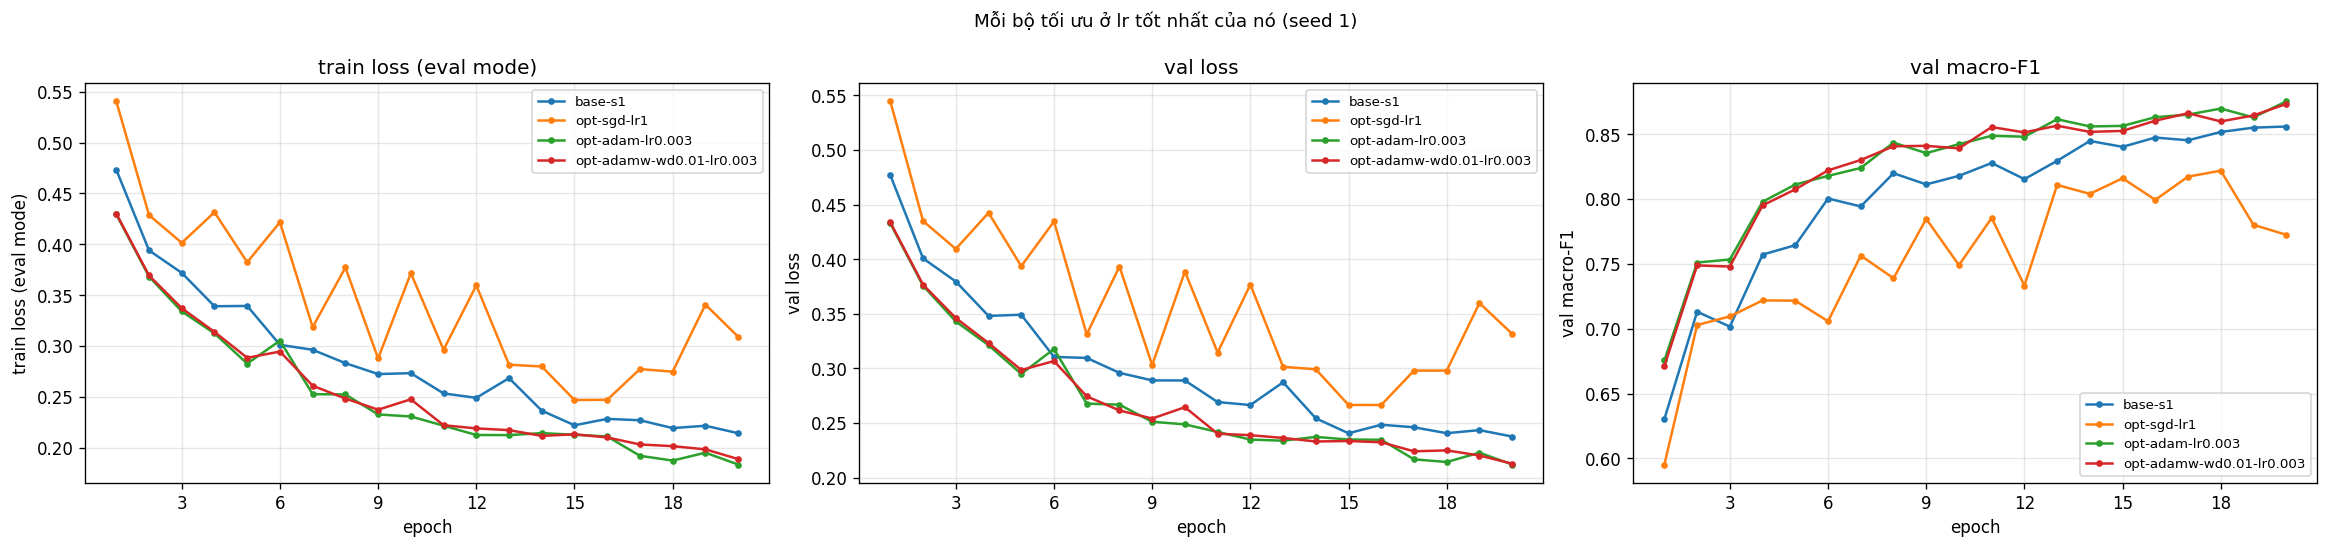

In [15]:
# 3.4 lr tốt nhất của từng bộ (theo seed 1) -> chạy thêm seed 2-5. SGD+momentum: base-s1..s5 (lr 0.1 = lr tốt nhất của nó)
ORDER = ["sgd_momentum", "sgd", "adam", "adamw"]
BEST = {o: best_lr(sweeps[o]) for o in ORDER}
seed_runs = {"sgd_momentum": base_runs}
for o in ORDER[1:]:
    r1 = sweeps[o][BEST[o]]
    seed_runs[o] = [r1] + [run_and_save({**r1["cfg"], "seed": s, "exp_id": f"{r1['cfg']['exp_id']}-s{s}",
                                         "description": r1["cfg"]["description"] + f", seed {s}"}) for s in SEEDS[1:]]

base_mean, two_sigma = NOISE["val_macro_f1"]["mean"], NOISE["val_macro_f1"]["two_sigma"]
print(f"\n{'bộ tối ưu':>13s} {'lr*':>7s} {'val_f1 TB±std (5 seed)':>23s} {'TB seed 2-5':>11s} {'val_acc TB±std':>16s} "
      f"{'best_val_loss':>13s} {'best_ep':>9s} {'s/epoch':>7s} {'Δf1 vs base':>11s} {'> 2σ?':>6s}")
OPT_STATS = {}
for o in ORDER:
    rs = seed_runs[o]
    f1 = np.array([r["summary"]["val_macro_f1"] for r in rs]); acc = np.array([r["summary"]["val_acc"] for r in rs])
    vl = np.array([r["summary"]["best_val_loss"] for r in rs]); ep = [r["summary"]["best_epoch"] for r in rs]
    t = np.mean([r["summary"]["time_per_epoch_s"] for r in rs])
    OPT_STATS[o] = dict(lr=BEST[o], f1_mean=f1.mean(), f1_std=f1.std(ddof=1), f1_mean_s2_5=f1[1:].mean(),
                        acc_mean=acc.mean(), acc_std=acc.std(ddof=1), loss_mean=vl.mean(), delta=f1.mean() - base_mean)
    st = OPT_STATS[o]
    print(f"{OPT_LABEL[o]:>13s} {BEST[o]:>7g} {st['f1_mean']:>14.4f} ± {st['f1_std']:.4f} {st['f1_mean_s2_5']:>11.4f} "
          f"{st['acc_mean']:>9.4f} ± {st['acc_std']:.4f} {st['loss_mean']:>13.4f} {min(ep):>4d}-{max(ep):<4d} {t:>7.2f} "
          f"{st['delta']:>+11.4f} {('Có' if abs(st['delta']) > two_sigma else 'Không') if o != 'sgd_momentum' else '—':>6s}")

# Luật chọn đặt trước: val macro-F1 trung bình 5 seed cao nhất; mô hình nộp = seed 1 của cấu hình đó
FINAL_OPT = max(ORDER, key=lambda o: OPT_STATS[o]["f1_mean"])
FINAL_RUN = seed_runs[FINAL_OPT][0]
print(f"\n-> CẤU HÌNH CUỐI CÙNG (chọn bằng val): {OPT_LABEL[FINAL_OPT]} lr={BEST[FINAL_OPT]:g}; "
      f"mô hình nộp = {FINAL_RUN['cfg']['exp_id']} (seed {FINAL_RUN['cfg']['seed']})")

plot_lr_sensitivity({OPT_LABEL[o]: list(sweeps[o].values()) for o in ORDER}, f"{OUT_DIR}/figures/compare_optimizer_lr.png",
                    seed_runs={OPT_LABEL[o]: seed_runs[o] for o in ORDER},
                    title="Độ nhạy với lr của từng bộ tối ưu (đường: quét lr, seed 1; ô vuông: TB ± std 5 seed ở lr tốt nhất)")
plot_compare([seed_runs[o][0] for o in ORDER], ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_optimizer.png",
             title="Mỗi bộ tối ưu ở lr tốt nhất của nó (seed 1)")
display(Image(f"{OUT_DIR}/figures/compare_optimizer_lr.png"))
display(Image(f"{OUT_DIR}/figures/compare_optimizer.png"))

**Đối chiếu sau khi chạy (3.4) và kết luận chủ đề `optimizer`:** 
- **Thứ hạng ở lr tốt nhất (5 seed):** Adam 0,8705 ± 0,0046 ≈ AdamW 0,8673 ± 0,0056 > SGD+momentum 0,8560 ± 0,0030 > SGD 0,8315 ± 0,0203. So với dự đoán: phần "Adam ≈ AdamW > SGD+momentum" đúng; phần "SGD ≈ SGD+momentum" sai (SGD kém hơn, vượt 2σ; xem 3.1).
- **Ước lượng không thiên lệch (chỉ seed 2–5):** Adam 0,8693, AdamW 0,8658, SGD+momentum 0,8561, SGD 0,8395. Thứ hạng không đổi, và Adam vẫn hơn baseline +0,013 > 2σ. Hiệu ứng "winner's curse" với Adam nhỏ (seed 1 cao hơn trung bình seed 2–5 là 0,006), còn với SGD thì ngược chiều.
- **Độ nhạy lr** (`compare_optimizer_lr.png`): lr tốt nhất của các họ bộ tối ưu cách nhau 1,5–2,5 bậc độ lớn (Adam 3e-3, SGD+momentum 0,1, SGD 1). Nếu dùng một lr chung cho mọi bộ, kết luận sẽ sai lệch nặng. Ví dụ ở lr = 0,1, SGD (0,740) thua SGD+momentum (0,856) tới 0,116; nhưng ở lr tốt nhất của mỗi bên, khoảng cách chỉ còn 0,025, nên phần lớn chênh lệch kia là do SGD bị chạy với lr quá nhỏ. Quanh lr tốt nhất, Adam và SGD+momentum giữ macro-F1 ≥ 0,82 trên một khoảng lr rộng khoảng 10 lần (Adam 1e-3–1e-2: 0,843–0,875; SGD+momentum 0,03–0,3: 0,825–0,856). SGD có khoảng tốt hẹp hơn và rơi mạnh ở lr = 3.
- **Chi phí:** Adam/AdamW mất 0,40–0,41 s/epoch so với 0,34 s của SGD+momentum, tức chậm hơn khoảng 20% vì phải giữ và cập nhật thêm hai trạng thái m, v cho mỗi tham số. Đổi lại được +0,0145 val macro-F1.
- **Cấu hình cuối cùng** (theo luật đã đặt trước): **Adam, lr = 3e-3**, mọi thứ khác như baseline. Mô hình nộp là `opt-adam-lr0.003` (seed 1, val macro-F1 0,8753). Seed này nằm ở phía trên của khoảng 5 seed, nên điểm eval của nó có thể lạc quan hơn kỳ vọng khoảng 0,005.

### 3.5 — Kiểm tra cơ chế của 3.2 trên val: lớp nào hưởng lợi?
Dự đoán ở 3.2 nói phần cải thiện của Adam chủ yếu đến từ các lớp hiếm. Kiểm tra trực tiếp bằng F1 từng lớp trên **val**.

In [16]:
# 3.5 Kiểm tra cơ chế trên VAL (không dùng eval): lớp nào hưởng lợi khi đổi sang bộ tối ưu của cấu hình cuối?
#     F1 từng lớp trên val, seed 1, trọng số best_state; baseline base-s1 so với FINAL_RUN
def per_class_val(run):
    m = MLP(tuple(run["cfg"]["hidden"]), dropout=run["cfg"]["dropout"], init=run["cfg"]["init"]).to(device)
    m.load_state_dict(run["best_state"])
    p, t = predict(m, X_val).cpu().numpy(), y_val.cpu().numpy()
    cmv = np.zeros((7, 7), dtype=np.int64)
    np.add.at(cmv, (t, p), 1)
    tp = np.diag(cmv).astype(float)
    prec, rec = tp / np.maximum(cmv.sum(0), 1), tp / cmv.sum(1)
    return np.where(prec + rec > 0, 2 * prec * rec / np.maximum(prec + rec, 1e-12), 0.0), cmv

f1_b, cm_vb = per_class_val(base_runs[0])
f1_f, cm_vf = per_class_val(FINAL_RUN)
print(f"{'lớp':>3s} {'n val':>6s} {'%':>6s} {'F1 base-s1':>10s} {'F1 ' + FINAL_RUN['cfg']['exp_id']:>20s} {'ΔF1':>7s}")
for c in np.argsort(-cm_vb.sum(1)):
    print(f"{c:>3d} {cm_vb[c].sum():>6d} {100 * cm_vb[c].sum() / cm_vb.sum():>6.2f} {f1_b[c]:>10.4f} {f1_f[c]:>20.4f} {f1_f[c] - f1_b[c]:>+7.4f}")
print(f"macro-F1: {f1_b.mean():.4f} -> {f1_f.mean():.4f};  tỉ lệ lớp 4 bị đoán thành lớp 1: "
      f"{cm_vb[4, 1] / cm_vb[4].sum():.3f} -> {cm_vf[4, 1] / cm_vf[4].sum():.3f}")

lớp  n val      % F1 base-s1  F1 opt-adam-lr0.003     ΔF1
  1  45328  48.76     0.9224               0.9277 +0.0053
  0  33894  36.46     0.8989               0.9105 +0.0116
  2   5721   6.15     0.8968               0.9122 +0.0154
  6   3282   3.53     0.9028               0.9330 +0.0302
  5   2779   2.99     0.8231               0.8399 +0.0169
  4   1519   1.63     0.7608               0.7851 +0.0244
  3    439   0.47     0.7869               0.8188 +0.0319
macro-F1: 0.8560 -> 0.8753;  tỉ lệ lớp 4 bị đoán thành lớp 1: 0.255 -> 0.180


**Nhận xét 3.5:** 
- Đúng dự đoán của 3.2. Lớp lớn nhất (lớp 1, 48,8%) chỉ tăng +0,005 F1 và lớp 0 tăng +0,012. Trong khi đó các lớp nhỏ (lớp 2–6) tăng +0,015 đến +0,032, tức gấp khoảng 3–6 lần lớp 1: lớp 3 (0,47%) +0,032, lớp 6 +0,030, lớp 4 +0,024, lớp 5 +0,017, lớp 2 +0,015. Tỉ lệ lớp 4 (Aspen) bị đoán thành lớp 1 giảm từ 25,5% xuống 18,0%.
- Vì macro-F1 lấy trung bình không trọng số qua 7 lớp, cải thiện ở các lớp hiếm đóng góp phần lớn vào mức +0,019 macro-F1, trong khi accuracy (bị lớp 0 và 1 chi phối) chỉ tăng +0,010.
- Thận trọng: đây là so sánh một seed. F1 của lớp 3 dựa trên chỉ 439 mẫu val nên tự nó đã nhiễu; chỉ nên đọc xu hướng chung "lớp hiếm hưởng lợi nhiều hơn", không đọc từng con số riêng lẻ.

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [ ]:
# TODO: chọn cấu hình cuối cùng theo VAL (có thể là baseline nếu bạn không kết hợp thêm gì)
# TODO: final_eval(cfg_final, result_final, data, f"{OUT_DIR}/predictions_eval.csv")
# TODO: chạy: python scripts/evaluate.py --pred <OUT_DIR>/predictions_eval.csv --out <OUT_DIR>/eval_result.json (từ REPO_ROOT)
# TODO: đọc eval_result.json: ghi accuracy, macro_f1 vào bảng và báo cáo; làm tương tự cho baseline (predictions riêng, không nộp nếu không cần)

In [ ]:
# TODO: phân tích lỗi trên eval: bảng precision/recall/F1 theo lớp (từ eval_result.json) và ma trận nhầm lẫn;
#       lớp nào khó nhất? vì sao (số mẫu ít? nhầm với lớp nào?)  -> viết nhận xét ở ô markdown bên dưới

**Phân tích lỗi (tự viết):** ...

In [ ]:
# TODO: results = load_results(f"{OUT_DIR}/results"); rows = [to_row(r, ...) for r in results]
# TODO: write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx")
# TODO: bổ sung sheet Seeds (exp_id các lần chạy baseline) và nhận xét ở sheet Summary